In [55]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper()
)

print(wiki.invoke("Artificial Intelligence"))

Page: Artificial intelligence
Summary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.
The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for 

In [56]:

import arxiv
from langchain_core.tools import tool

@tool
def search_arxiv(query: str):
    """ This tool is used for research papers"""
    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2
    )

    results = client.results(search)

    output = []
    for paper in results:
        output.append({
            "title": paper.title,
            "summary": paper.summary
        })

    return output

In [57]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")




In [58]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [59]:
tavily.invoke("provide me the recent ai news")

[{'title': 'Agentic AI News + AI Breakthroughs + AI Developments | 2026',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': "Wondering what's happening in the AI world? Here are the latest AI breakthroughs and news that are shaping the world around us!",
  'score': 0.99248135},
 {'title': 'Artificial Intelligence News -- ScienceDaily',
  'url': 'https://www.sciencedaily.com/news/computers_math/artificial_intelligence/',
  'content': 'ScienceDaily\n\n# Artificial Intelligence News\n\n## Top Headlines\n\n## Latest Headlines\n\n## Earlier Headlines\n\n### Tuesday, February 10, 2026\n\n### Friday, February 6, 2026\n\n### Saturday, January 31, 2026\n\n### Thursday, January 29, 2026\n\n### Monday, February 2, 2026\n\n### Wednesday, January 28, 2026\n\n### Sunday, January 25, 2026\n\n### Friday, January 16, 2026\n\n### Tuesday, January 20, 2026\n\n### Friday, January 9, 2026\n\n### Wednesday, January 7, 2026\n\n### Sunday, December 21, 2025\n\n### Monday, Decem

In [60]:
# combine all the tools in the list for our llm
tools =[search_arxiv,wiki,tavily]

In [61]:
# initilize our llm model
from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-sonnet-4-5")

In [62]:
llm.invoke("what is ai?")

AIMessage(content="# What is AI?\n\n**AI (Artificial Intelligence)** refers to computer systems designed to perform tasks that typically require human intelligence.\n\n## Key Capabilities\n\nAI systems can:\n- **Learn** from data and experience\n- **Reason** and solve problems\n- **Understand** language\n- **Recognize** patterns (images, speech, etc.)\n- **Make decisions** based on information\n\n## Common Examples\n\n- **Virtual assistants** (Siri, Alexa)\n- **Recommendation systems** (Netflix, Spotify)\n- **Image recognition** (face unlock, medical diagnostics)\n- **Autonomous vehicles**\n- **Chatbots and conversational agents** (like me!)\n\n## Types of AI\n\n1. **Narrow AI** - Designed for specific tasks (most current AI)\n2. **General AI** - Human-level intelligence across all domains (still theoretical)\n\n## How It Works\n\nMost modern AI uses **machine learning**, where systems learn patterns from large amounts of data rather than being explicitly programmed with rules.\n\nIs t

In [ ]:
from langchain_groq import ChatGroq

model = ChatGroq(model="qwen/qwen3-32b")

In [63]:
model.invoke("what is os?")

AIMessage(content='<think>\nOkay, the user is asking, "what is os?" So first, I need to figure out what they mean by "os." The most common interpretation is the operating system, which is a fundamental part of any computer. But maybe they meant something else, like an organization, a company, or another abbreviation. However, given the context is likely technical since they asked on a platform where programming or tech questions are common.\n\nLet me start by confirming the primary meaning. Operating System (OS) is the most probable answer. I should explain that it\'s software that manages hardware and software resources, provides services for programs, and acts as an intermediary between applications and the computer hardware. Examples include Windows, macOS, Linux, Android, iOS, etc.\n\nI should break down the explanation into parts: definition, key functions, examples, and maybe some common types. That way, it\'s structured and easy to follow. Also, mention the role in user interfac

In [95]:
model_with_tools=llm.bind_tools(tools=tools)

In [96]:
model_with_tools.invoke("what is the recent news on AI?")

AIMessage(content=[{'text': "I'll search for recent news on AI for you.", 'type': 'text'}, {'id': 'toolu_01XuNJSt8z5HDuNxBPrqMSqN', 'caller': {'type': 'direct'}, 'input': {'query': 'recent AI news artificial intelligence latest developments'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_019zdRtTJNDJhxkewuQ3h2YM', 'container': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 757, 'output_tokens': 76, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-5-20250929', 'model_provider': 'anthropic'}, id='lc_run--019e41d6-991e-7ab2-808d-cce047a887e4-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '

In [97]:
model_with_tools.invoke("what is the latest research on quantum computing?")

AIMessage(content=[{'text': "I'll search for the latest research on quantum computing for you.", 'type': 'text'}, {'id': 'toolu_016B517EKrh7ESRKusDU2Ujd', 'caller': {'type': 'direct'}, 'input': {'query': 'quantum computing'}, 'name': 'search_arxiv', 'type': 'tool_use'}, {'id': 'toolu_01Rh2bU45GhznQGvaHWxdjf1', 'caller': {'type': 'direct'}, 'input': {'query': 'latest quantum computing research 2024'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01WvtSNLBiBfQWexmsWu97JV', 'container': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 758, 'output_tokens': 116, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-5-20250

Workflow

In [98]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages 

In [100]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


In [101]:
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


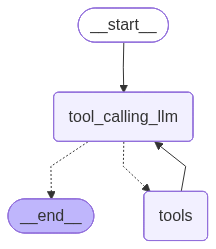

In [102]:
from IPython.display import display,Image
# node define for ai assistant
def tool_calling_llm(state:State):
    return {"messages":[model_with_tools.invoke(state["messages"])]}

# build the graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")
builder.add_edge("tool_calling_llm",END)


graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [103]:

response = graph.invoke({"messages":"1706.03762"})
for r in response['messages']:
    r.pretty_print() 

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================

[{'id': 'toolu_018nTDfH1mX4Lgvy9XUWkoU8', 'caller': {'type': 'direct'}, 'input': {'query': '1706.03762'}, 'name': 'search_arxiv', 'type': 'tool_use'}]
Tool Calls:
  search_arxiv (toolu_018nTDfH1mX4Lgvy9XUWkoU8)
 Call ID: toolu_018nTDfH1mX4Lgvy9XUWkoU8
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: search_arxiv

[{"title": "Attention Is All You Need", "summary": "The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entire

In [90]:
response = graph.invoke({"messages":"Hey my name is abhi"})
for r in response['messages']:
    r.pretty_print() 
    

================================ Human Message =================================

Hey my name is abhi
================================== Ai Message ==================================

Hello Abhi! How can I assist you today? 😊


In [104]:

response = graph.invoke({"messages":"hey give me recent news on ai then  please tell me the recent research paper on quantum computing"})
for r in response['messages']:
    r.pretty_print() 

================================ Human Message =================================

hey give me recent news on ai then  please tell me the recent research paper on quantum computing
================================== Ai Message ==================================

[{'text': "I'll help you find recent news on AI and research papers on quantum computing.", 'type': 'text'}, {'id': 'toolu_01ScJMf45D6AX4eoM6uifs4N', 'caller': {'type': 'direct'}, 'input': {'query': 'recent AI news artificial intelligence 2024'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}, {'id': 'toolu_016ZsiRtktcwVrnfDVLEbWyy', 'caller': {'type': 'direct'}, 'input': {'query': 'quantum computing'}, 'name': 'search_arxiv', 'type': 'tool_use'}]
Tool Calls:
  tavily_search_results_json (toolu_01ScJMf45D6AX4eoM6uifs4N)
 Call ID: toolu_01ScJMf45D6AX4eoM6uifs4N
  Args:
    query: recent AI news artificial intelligence 2024
  search_arxiv (toolu_016ZsiRtktcwVrnfDVLEbWyy)
 Call ID: toolu_016ZsiRtktcwVrnfDVLEbWyy
  Args:
